# Receipt Evidence Fraud Detection Using Computer Vision

This notebook records the computer vision work I completed for the receipt evidence part of ShieldWise. The aim was to test whether receipt images could be prepared, labelled, trained on, and evaluated in a way that supports the wider insurance fraud workflow.

I have kept the workflow practical and easy to follow: load the dataset, inspect the labels, prepare image batches, train MobileNetV2 and ResNet50, compare the results, and save the model artefacts.


## 1. Environment Setup and Imports

This section loads the libraries needed for image processing, model training, plotting, and evaluation. I also set up the working environment so the notebook can be rerun more consistently.


In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
# Core Libraries
import os
import json
import random
import warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as patches
import seaborn as sns
from collections import defaultdict

# Deep Learning
import tensorflow as tf
from tensorflow.keras.applications import MobileNetV2, ResNet50
from tensorflow.keras.layers import (
    GlobalAveragePooling2D, Dense, Dropout, BatchNormalization
)
from tensorflow.keras.models import Model
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import (
    EarlyStopping, ModelCheckpoint, ReduceLROnPlateau
)
from tensorflow.keras.preprocessing.image import (
    ImageDataGenerator, load_img, img_to_array
)

# Evaluation
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score,
    f1_score, confusion_matrix, classification_report,
    roc_auc_score, roc_curve
)

# Reproducibility
RANDOM_SEED = 42
random.seed(RANDOM_SEED)
np.random.seed(RANDOM_SEED)
tf.random.set_seed(RANDOM_SEED)
warnings.filterwarnings('ignore')

# Output Directories
os.makeirs('/content/drive/MyDrive/Colab Notebooks/Osas/deep/saved_models', exist_ok=True)
os.makedirs('/content/drive/MyDrive/Colab Notebooks/Osas/deep/plots', exist_ok=True)


In [ ]:
#  Output Directories (Google Drive)
SAVE_PATH = '/content/drive/MyDrive/Colab Notebooks/Osas/deep/saved_models'
PLOTS_PATH = '/content/drive/MyDrive/Colab Notebooks/Osas/deep/plots'
os.makedirs(SAVE_PATH, exist_ok=True)
os.makedirs(PLOTS_PATH, exist_ok=True)

 All libraries imported successfully.
TensorFlow : 2.19.0
NumPy      : 2.0.2
Pandas     : 2.2.2
Save path  : /content/drive/MyDrive/Colab Notebooks/Osas/deep/saved_models


---
## 2. Dataset Loading and COCO Annotation Parsing
<a id='2'></a>

The receipt dataset uses COCO-style annotations. Each image can have zero or more labelled bounding boxes, usually connected to fraud or damage indicators.

For this project, I converted those annotations into a simple image-level classification task. If a receipt has at least one fraud or damage annotation, it is treated as `Fraudulent`. If it has no annotation, it is treated as `Legitimate`. This keeps the task understandable while still linking the model to the evidence-checking part of the insurance system.


In [ ]:
#  Dataset Path Configuration
DATASET_ROOT  = '/content/drive/MyDrive/Colab Notebooks/Osas/Receipt_Fraud'
ANNOTATION_FILE = '_annotations_coco.json'

SPLITS = {
    'train': os.path.join(DATASET_ROOT, 'train'),
    'valid': os.path.join(DATASET_ROOT, 'valid'),
    'test' : os.path.join(DATASET_ROOT, 'test')
}

IMG_SIZE   = (224, 224)  # required input size for MobileNetV2 and ResNet50
BATCH_SIZE = 32
EPOCHS     = 10          # Training epochs

print('Dataset split paths:')
for split, path in SPLITS.items():
    exists = '' if os.path.exists(path) else ' NOT FOUND'
    print(f'  {split:6s}  {path}  {exists}')

Dataset split paths:
  train   /content/drive/MyDrive/Colab Notebooks/Osas/Receipt_Fraud/train  
  valid   /content/drive/MyDrive/Colab Notebooks/Osas/Receipt_Fraud/valid  
  test    /content/drive/MyDrive/Colab Notebooks/Osas/Receipt_Fraud/test  


In [ ]:
#  COCO Annotation Parser
def parse_coco_annotations(split_dir, annotation_file):
    """
    Reads a COCO JSON annotation file from a split folder and returns
    a DataFrame with one row per image, containing:
      - filepath  : full path to the image
      - label     : '1' if any fraud/damage annotation exists, '0' otherwise
      - label_name: human-readable label
      - n_annotations: number of bounding boxes on this image
      - categories: list of annotation category names on this image
    """
    json_path = os.path.join(split_dir, annotation_file)

    with open(json_path, 'r') as f:
        coco = json.load(f)

    # Build category id  name lookup
    cat_lookup = {cat['id']: cat['name'] for cat in coco['categories']}

    # Build image id  annotations lookup
    img_annotations = defaultdict(list)
    for ann in coco['annotations']:
        img_annotations[ann['image_id']].append(cat_lookup[ann['category_id']])

    records = []
    for img_info in coco['images']:
        img_id   = img_info['id']
        fname    = img_info['file_name']
        fpath    = os.path.join(split_dir, fname)
        ann_cats = img_annotations.get(img_id, [])  # empty list = legitimate

        # Binary label: any annotation = fraudulent
        label = '1' if len(ann_cats) > 0 else '0'

        records.append({
            'filepath'      : fpath,
            'label'         : label,
            'label_name'    : 'Fraudulent' if label == '1' else 'Legitimate',
            'n_annotations' : len(ann_cats),
            'categories'    : ann_cats
        })

    return pd.DataFrame(records)


#  Parse All Splits
train_df = parse_coco_annotations(SPLITS['train'], ANNOTATION_FILE)
valid_df = parse_coco_annotations(SPLITS['valid'], ANNOTATION_FILE)
test_df  = parse_coco_annotations(SPLITS['test'],  ANNOTATION_FILE)

print(f'Train : {len(train_df)} images')
print(f'Valid : {len(valid_df)} images')
print(f'Test  : {len(test_df)} images')
print(f'Total : {len(train_df) + len(valid_df) + len(test_df)} images')

train_df.head(10)

Train : 1107 images
Valid : 105 images
Test  : 53 images
Total : 1265 images


,filepath,label,label_name,n_annotations,categories
0,/content/drive/MyDrive/Colab Notebooks/Osas/Re...,1,Fraudulent,1,[fraud]
1,/content/drive/MyDrive/Colab Notebooks/Osas/Re...,1,Fraudulent,1,[fraud]
2,/content/drive/MyDrive/Colab Notebooks/Osas/Re...,1,Fraudulent,2,"[fraud, fraud]"
3,/content/drive/MyDrive/Colab Notebooks/Osas/Re...,1,Fraudulent,1,[fraud]
4,/content/drive/MyDrive/Colab Notebooks/Osas/Re...,1,Fraudulent,1,[fraud]
5,/content/drive/MyDrive/Colab Notebooks/Osas/Re...,1,Fraudulent,5,"[fraud, fraud, fraud, fraud, fraud]"
6,/content/drive/MyDrive/Colab Notebooks/Osas/Re...,1,Fraudulent,1,[fraud]
7,/content/drive/MyDrive/Colab Notebooks/Osas/Re...,1,Fraudulent,4,"[fraud, fraud, fraud, fraud]"
8,/content/drive/MyDrive/Colab Notebooks/Osas/Re...,1,Fraudulent,2,"[damage, damage]"
9,/content/drive/MyDrive/Colab Notebooks/Osas/Re...,1,Fraudulent,2,"[damage, damage]"


In [ ]:
#  Class Distribution Per Split
print('Class distribution per split:')
for name, df in [('Train', train_df), ('Valid', valid_df), ('Test', test_df)]:
    counts = df['label_name'].value_counts()
    total  = len(df)
    print(f'\n  {name}:')
    for cls, cnt in counts.items():
        print(f'    {cls:12s}: {cnt:4d}  ({cnt/total*100:.1f}%)')

Class distribution per split:

  Train:
    Fraudulent  : 1104  (99.7%)
    Legitimate  :    3  (0.3%)

  Valid:
    Fraudulent  :  104  (99.0%)
    Legitimate  :    1  (1.0%)

  Test:
    Fraudulent  :   53  (100.0%)


## 3. Exploratory Data Analysis

This section checks the dataset before training. I look at the number of images, the class balance, and the annotation pattern so that the model results can be explained honestly later in the report.


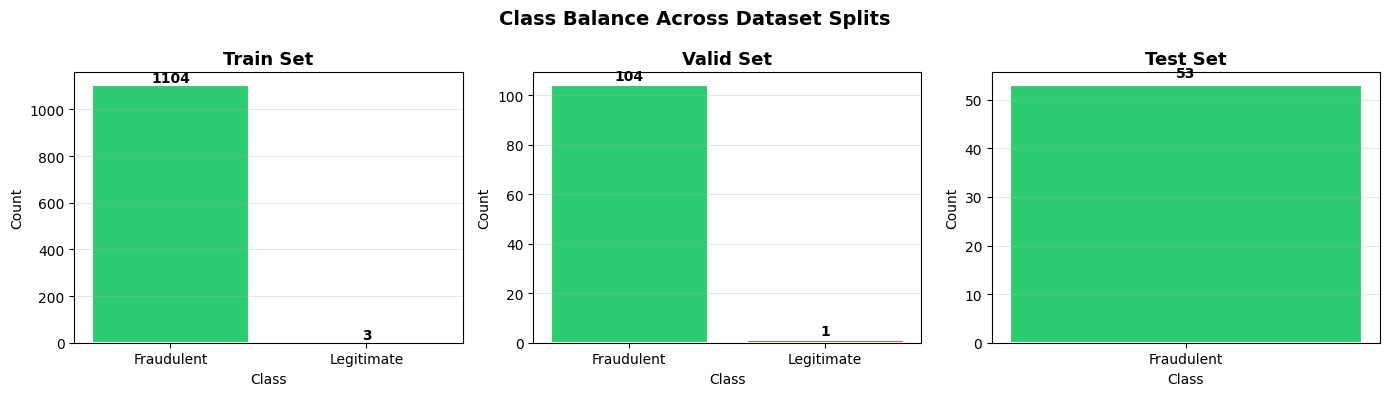

In [ ]:
#  Class Balance Plot
fig, axes = plt.subplots(1, 3, figsize=(14, 4))

for ax, (name, df) in zip(axes, [('Train', train_df), ('Valid', valid_df), ('Test', test_df)]):
    counts = df['label_name'].value_counts()
    colors = ['#2ecc71', '#e74c3c']
    bars = ax.bar(counts.index, counts.values, color=colors, edgecolor='white', linewidth=1.5)
    ax.set_title(f'{name} Set', fontsize=13, fontweight='bold')
    ax.set_ylabel('Count')
    ax.set_xlabel('Class')
    for bar, val in zip(bars, counts.values):
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 1,
                str(val), ha='center', va='bottom', fontweight='bold')
    ax.grid(True, alpha=0.3, axis='y')

plt.suptitle('Class Balance Across Dataset Splits', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig(f'{PLOTS_PATH}/class_balance.png', dpi=150)
plt.show()

Annotation categories in training set:
fraud     1806
damage     450
Name: count, dtype: int64


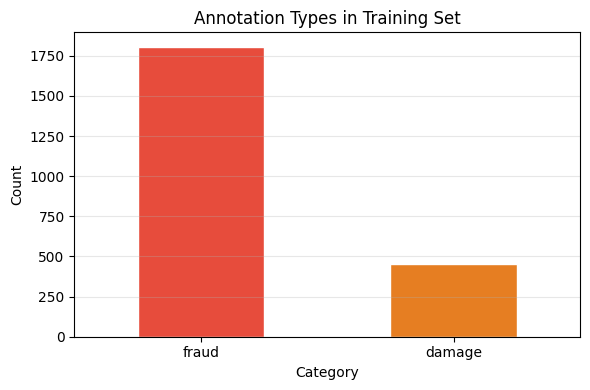

In [ ]:
#  Annotation Category Distribution
# Flatten all category lists in training set to count occurrences
all_cats = [cat for cats in train_df['categories'] for cat in cats]
cat_series = pd.Series(all_cats)

print('Annotation categories in training set:')
print(cat_series.value_counts())

fig, ax = plt.subplots(figsize=(6, 4))
cat_series.value_counts().plot(kind='bar', ax=ax, color=['#e74c3c', '#e67e22'],
                                edgecolor='white')
ax.set_title('Annotation Types in Training Set')
ax.set_xlabel('Category')
ax.set_ylabel('Count')
ax.tick_params(axis='x', rotation=0)
ax.grid(True, alpha=0.3, axis='y')
plt.tight_layout()
plt.savefig(f'{PLOTS_PATH}/annotation_distribution.png', dpi=150)
plt.show()

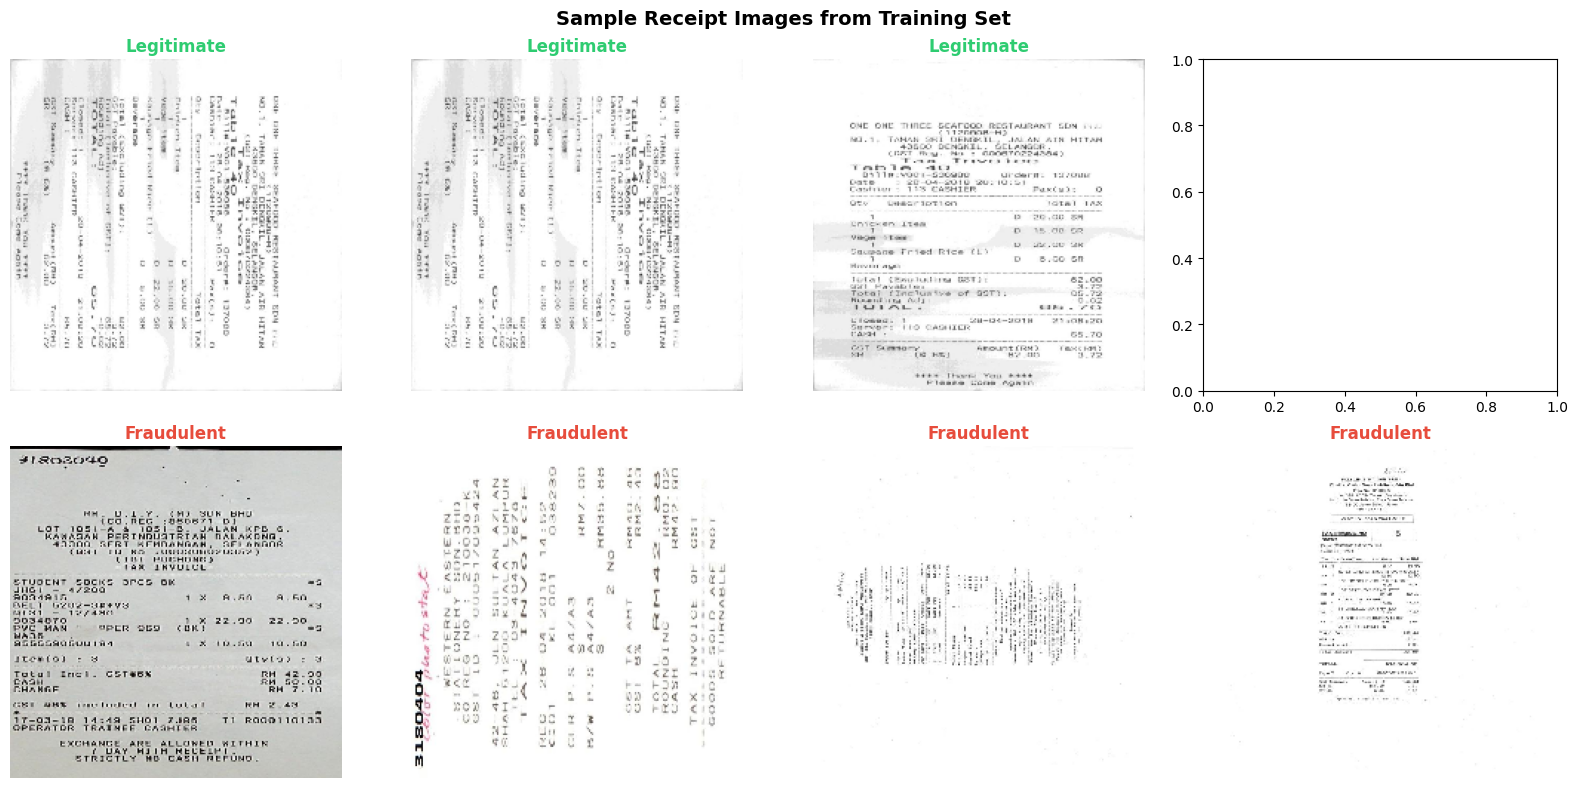

In [ ]:
#  Sample Images Visualisation
# Show 4 legitimate and 4 fraudulent receipts from the training set
fig, axes = plt.subplots(2, 4, figsize=(16, 8))

for row, label_val in enumerate(['0', '1']):
    label_name = 'Legitimate' if label_val == '0' else 'Fraudulent'
    samples = train_df[train_df['label'] == label_val].sample(
        n=min(4, len(train_df[train_df['label'] == label_val])),
        random_state=RANDOM_SEED
    )
    for col, (_, row_data) in enumerate(samples.iterrows()):
        ax = axes[row][col]
        try:
            img = load_img(row_data['filepath'], target_size=IMG_SIZE)
            ax.imshow(img)
            color = '#2ecc71' if label_val == '0' else '#e74c3c'
            ax.set_title(label_name, color=color, fontweight='bold')
        except Exception:
            ax.text(0.5, 0.5, 'Image not found', ha='center', va='center',
                    transform=ax.transAxes)
        ax.axis('off')

plt.suptitle('Sample Receipt Images from Training Set', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig(f'{PLOTS_PATH}/sample_images.png', dpi=150)
plt.show()

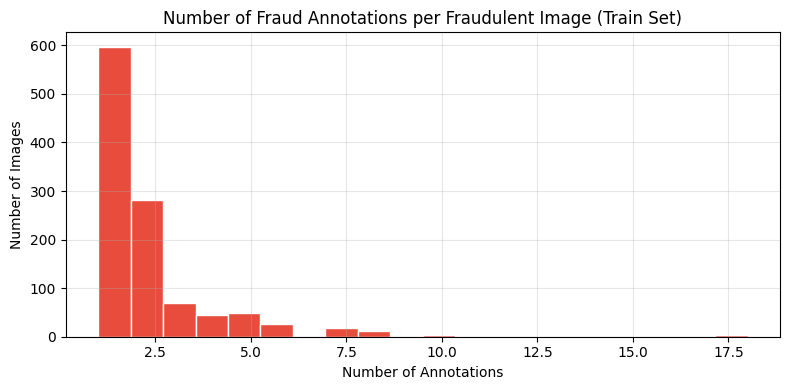

Avg annotations per fraudulent image : 2.04
Max annotations on a single image    : 18


In [ ]:
#  Annotation Count Distribution
# How many bounding boxes do fraudulent images tend to have?
fraudulent = train_df[train_df['label'] == '1']

fig, ax = plt.subplots(figsize=(8, 4))
ax.hist(fraudulent['n_annotations'], bins=20, color='#e74c3c', edgecolor='white')
ax.set_title('Number of Fraud Annotations per Fraudulent Image (Train Set)')
ax.set_xlabel('Number of Annotations')
ax.set_ylabel('Number of Images')
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig(f'{PLOTS_PATH}/annotation_count_distribution.png', dpi=150)
plt.show()

print(f'Avg annotations per fraudulent image : {fraudulent["n_annotations"].mean():.2f}')
print(f'Max annotations on a single image    : {fraudulent["n_annotations"].max()}')

---
## 4. Data Preparation and Generators
<a id='4'></a>

The dataset already comes with `train`, `valid`, and `test` folders, so I use those splits instead of creating new ones. This avoids mixing examples between training and testing.

The training images are lightly augmented to help the model cope with small changes in receipt position, lighting, and scale. Validation and test images are kept clean so the evaluation remains fair.


In [ ]:
#  Check for Class Imbalance & Compute Class Weights
from sklearn.utils.class_weight import compute_class_weight

y_train_int = train_df['label'].astype(int).values
classes     = np.unique(y_train_int)

#  Imbalance Strategy: Mild Class Weights + Threshold Tuning
# Auto-balanced weights can be extreme (e.g. 184x) and destabilise training.
# Instead we use mild fixed weights to give the minority class a gentle boost,
# then rely on threshold tuning post-training to handle the remaining imbalance.
counts_train = train_df['label'].value_counts()
n_legit  = counts_train.get('0', 1)
n_fraud  = counts_train.get('1', 1)
ratio    = n_fraud / max(n_legit, 1)

# Cap weight at 10x to avoid instability  threshold tuning handles the rest
legit_weight = min(ratio, 10.0)
class_weight_dict = {0: legit_weight, 1: 1.0}

print(f'Dataset ratio   Fraudulent : Legitimate = {n_fraud} : {n_legit}  ({ratio:.1f}x)')
print(f'Class weights   0 (Legitimate): {legit_weight:.2f}  |  1 (Fraudulent): 1.0')
print(f'Note: Using fixed 0.5 threshold for classification.')

#  Data Augmentation
# Training: apply augmentations to increase variation
train_datagen = ImageDataGenerator(
    rescale           = 1./255,
    rotation_range    = 10,
    width_shift_range = 0.1,
    height_shift_range= 0.1,
    shear_range       = 0.05,
    zoom_range        = 0.1,
    horizontal_flip   = True,
    brightness_range  = [0.85, 1.15]
)

# Validation and test: only rescale, no augmentation
eval_datagen = ImageDataGenerator(rescale=1./255)

print('\n Data generators configured.')

Dataset ratio   Fraudulent : Legitimate = 1104 : 3  (368.0x)
Class weights   0 (Legitimate): 10.00  |  1 (Fraudulent): 1.0
Note: Using fixed 0.5 threshold for classification.

 Data generators configured.


In [ ]:
#  Build Generators from DataFrames
def make_generator(datagen, df, shuffle=True):
    """
    Creates a Keras image generator from a DataFrame using
    flow_from_dataframe with binary class mode.
    """
    return datagen.flow_from_dataframe(
        dataframe  = df,
        x_col      = 'filepath',
        y_col      = 'label',
        target_size= IMG_SIZE,
        batch_size = BATCH_SIZE,
        class_mode = 'binary',
        classes    = ['0', '1'],  # force both classes always
        shuffle    = shuffle,
        seed       = RANDOM_SEED
    )


#  Check class distribution per split
print('Class counts per split before generator creation:')
for name, df in [('Train', train_df), ('Valid', valid_df), ('Test', test_df)]:
    counts = df['label'].value_counts().to_dict()
    print(f'  {name}: Legitimate(0)={counts.get("0",0)}  Fraudulent(1)={counts.get("1",0)}')

#  Fix: if test split is missing a class, merge with validation
test_classes = test_df['label'].nunique()
if test_classes < 2:
    print(f'\n  Test split only has {test_classes} class(es). Merging valid+test for evaluation.')
    test_df = pd.concat([valid_df, test_df], ignore_index=True)
    print(f'   Combined test set: {len(test_df)} images')
    counts = test_df['label'].value_counts().to_dict()
    print(f'   Legitimate(0)={counts.get("0",0)}  Fraudulent(1)={counts.get("1",0)}')
else:
    print(f'\n Test split has both classes  no merge needed.')

train_gen = make_generator(train_datagen, train_df, shuffle=True)
valid_gen = make_generator(eval_datagen,  valid_df, shuffle=False)
test_gen  = make_generator(eval_datagen,  test_df,  shuffle=False)

print(f'\nTrain generator : {train_gen.n} images | {train_gen.n // BATCH_SIZE + 1} batches/epoch')
print(f'Valid generator : {valid_gen.n} images')
print(f'Test  generator : {test_gen.n} images')
print(f'Class indices   : {train_gen.class_indices}   0=Legitimate, 1=Fraudulent')

Class counts per split before generator creation:
  Train: Legitimate(0)=3  Fraudulent(1)=1104
  Valid: Legitimate(0)=1  Fraudulent(1)=104
  Test: Legitimate(0)=0  Fraudulent(1)=53

  Test split only has 1 class(es). Merging valid+test for evaluation.
   Combined test set: 158 images
   Legitimate(0)=1  Fraudulent(1)=157
Found 1107 validated image filenames belonging to 2 classes.
Found 105 validated image filenames belonging to 2 classes.
Found 158 validated image filenames belonging to 2 classes.

Train generator : 1107 images | 35 batches/epoch
Valid generator : 105 images
Test  generator : 158 images
Class indices   : {'0': 0, '1': 1}   0=Legitimate, 1=Fraudulent


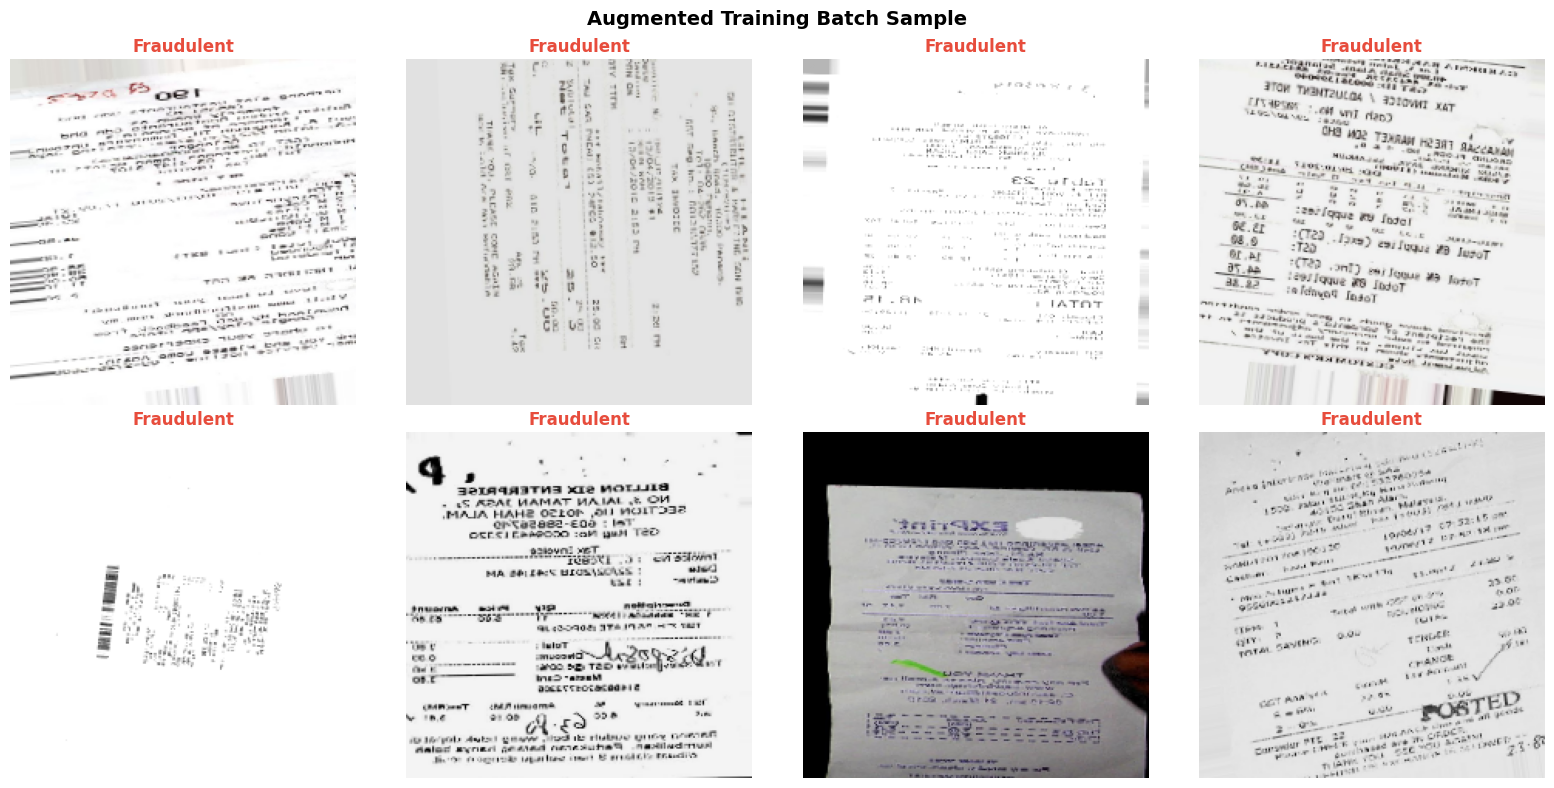

Found 1107 validated image filenames belonging to 2 classes.


In [ ]:
#  Visualise Augmented Training Samples
sample_batch_imgs, sample_batch_labels = next(train_gen)
label_map = {0: 'Legitimate', 1: 'Fraudulent'}

fig, axes = plt.subplots(2, 4, figsize=(16, 8))
for i, ax in enumerate(axes.flatten()):
    if i < len(sample_batch_imgs):
        ax.imshow(sample_batch_imgs[i])
        lbl = int(sample_batch_labels[i])
        color = '#2ecc71' if lbl == 0 else '#e74c3c'
        ax.set_title(label_map[lbl], color=color, fontweight='bold')
    ax.axis('off')

plt.suptitle('Augmented Training Batch Sample', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig(f'{PLOTS_PATH}/augmented_samples.png', dpi=150)
plt.show()

# Reset generator so training starts from the beginning
train_gen = make_generator(train_datagen, train_df, shuffle=True)

## 5. MobileNetV2 Training

MobileNetV2 is a lightweight convolutional neural network that is already trained on ImageNet. I used transfer learning by freezing the ImageNet base and training a new classification head for this receipt task.

This model is useful because it is faster and easier to run than a very large CNN, which makes it a sensible option for a prototype system.


In [ ]:
#  Build MobileNetV2
def build_mobilenet(img_size=IMG_SIZE):
    """
    Builds a binary classification model using MobileNetV2 as the backbone.
    The base is initialised with ImageNet weights and the top is replaced
    with a custom classification head.
    """
    base = MobileNetV2(
        weights     = 'imagenet',
        include_top = False,
        input_shape = (*img_size, 3)
    )
    base.trainable = False  # freeze base for Phase 1

    x = base.output
    x = GlobalAveragePooling2D()(x)
    x = BatchNormalization()(x)
    x = Dense(256, activation='relu')(x)
    x = Dropout(0.4)(x)
    x = Dense(64, activation='relu')(x)
    x = Dropout(0.2)(x)
    output = Dense(1, activation='sigmoid')(x)  # binary output

    model = Model(inputs=base.input, outputs=output)
    model.compile(
        optimizer = Adam(learning_rate=1e-3),
        loss      = 'binary_crossentropy',
        metrics   = ['accuracy']
    )
    return model, base

mobilenet_model, mobilenet_base = build_mobilenet()

print(f'Total params       : {mobilenet_model.count_params():,}')
print(f'Trainable params   : {sum([tf.size(w).numpy() for w in mobilenet_model.trainable_weights]):,}')
print(f'Non-trainable      : {sum([tf.size(w).numpy() for w in mobilenet_model.non_trainable_weights]):,}')

9406464/9406464 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
Total params       : 2,607,553
Trainable params   : 347,009
Non-trainable      : 2,260,544


In [ ]:
# -- Callbacks ----------------------------------------------------------------
callbacks_mn = [
    EarlyStopping(
        monitor              = 'val_loss',
        patience             = 5,
        restore_best_weights = True,
        verbose              = 1
    ),
    ModelCheckpoint(
        filepath             = f'{SAVE_PATH}/mobilenet_best.keras',
        monitor              = 'val_accuracy',
        save_best_only       = True,
        verbose              = 1
    ),
    ReduceLROnPlateau(
        monitor              = 'val_loss',
        factor               = 0.5,
        patience             = 3,
        min_lr               = 1e-7,
        verbose              = 1
    )
]

# Reset generators
train_gen = make_generator(train_datagen, train_df, shuffle=True)
valid_gen = make_generator(eval_datagen,  valid_df, shuffle=False)

print('Training MobileNetV2...')
history_mn = mobilenet_model.fit(
    train_gen,
    epochs          = EPOCHS,
    validation_data = valid_gen,
    class_weight    = class_weight_dict,
    callbacks       = callbacks_mn
)
print('MobileNetV2 training complete.')


Found 1107 validated image filenames belonging to 2 classes.
Found 105 validated image filenames belonging to 2 classes.
Training MobileNetV2...
Epoch 1/10
35/35 ━━━━━━━━━━━━━━━━━━━━ 0s 8s/step - accuracy: 0.8662 - loss: 0.3628
Epoch 1: val_accuracy improved from None to 0.99048, saving model to /content/drive/MyDrive/Colab Notebooks/Osas/deep/saved_models/mobilenet_best.keras

Epoch 1: finished saving model to /content/drive/MyDrive/Colab Notebooks/Osas/deep/saved_models/mobilenet_best.keras
35/35 ━━━━━━━━━━━━━━━━━━━━ 330s 9s/step - accuracy: 0.9603 - loss: 0.3360 - val_accuracy: 0.9905 - val_loss: 0.0595 - learning_rate: 0.0010
Epoch 2/10
35/35 ━━━━━━━━━━━━━━━━━━━━ 0s 2s/step - accuracy: 0.9981 - loss: 0.0624
Epoch 2: val_accuracy did not improve from 0.99048
35/35 ━━━━━━━━━━━━━━━━━━━━ 66s 2s/step - accuracy: 0.9955 - loss: 0.1088 - val_accuracy: 0.9905 - val_loss: 0.0565 - learning_rate: 0.0010
Epoch 3/10
35/35 ━━━━━━━━━━━━━━━━━━━━ 0s 2s/step - accuracy: 0.9984 - loss: 0.0564
Epoch 

## 6. ResNet50 Training

ResNet50 is a deeper convolutional neural network with residual connections. I trained it as a second model so I could compare a lightweight model against a stronger but more computationally expensive option.

Using both models helped me show the trade-off between speed, complexity, and classification performance.


In [ ]:
#  Build ResNet50
def build_resnet(img_size=IMG_SIZE):
    """
    Builds a binary classification model using ResNet50 as the backbone.
    The base is initialised with ImageNet weights and the top is replaced
    with a custom classification head.
    """
    base = ResNet50(
        weights     = 'imagenet',
        include_top = False,
        input_shape = (*img_size, 3)
    )
    base.trainable = False  # freeze base for Phase 1

    x = base.output
    x = GlobalAveragePooling2D()(x)
    x = BatchNormalization()(x)
    x = Dense(256, activation='relu')(x)
    x = Dropout(0.5)(x)
    x = Dense(64, activation='relu')(x)
    x = Dropout(0.3)(x)
    output = Dense(1, activation='sigmoid')(x)

    model = Model(inputs=base.input, outputs=output)
    model.compile(
        optimizer = Adam(learning_rate=1e-3),
        loss      = 'binary_crossentropy',
        metrics   = ['accuracy']
    )
    return model, base

resnet_model, resnet_base = build_resnet()

print(f'Total params       : {resnet_model.count_params():,}')
print(f'Trainable params   : {sum([tf.size(w).numpy() for w in resnet_model.trainable_weights]):,}')
print(f'Non-trainable      : {sum([tf.size(w).numpy() for w in resnet_model.non_trainable_weights]):,}')

94765736/94765736 ━━━━━━━━━━━━━━━━━━━━ 1s 0us/step
Total params       : 24,136,961
Trainable params   : 545,153
Non-trainable      : 23,591,808


In [ ]:
# -- Callbacks ----------------------------------------------------------------
callbacks_rn = [
    EarlyStopping(
        monitor              = 'val_loss',
        patience             = 5,
        restore_best_weights = True,
        verbose              = 1
    ),
    ModelCheckpoint(
        filepath             = f'{SAVE_PATH}/resnet50_best.keras',
        monitor              = 'val_accuracy',
        save_best_only       = True,
        verbose              = 1
    ),
    ReduceLROnPlateau(
        monitor              = 'val_loss',
        factor               = 0.5,
        patience             = 3,
        min_lr               = 1e-7,
        verbose              = 1
    )
]

# Reset generators
train_gen = make_generator(train_datagen, train_df, shuffle=True)
valid_gen = make_generator(eval_datagen,  valid_df, shuffle=False)

print('Training ResNet50...')
history_rn = resnet_model.fit(
    train_gen,
    epochs          = EPOCHS,
    validation_data = valid_gen,
    class_weight    = class_weight_dict,
    callbacks       = callbacks_rn
)
print('ResNet50 training complete.')


Found 1107 validated image filenames belonging to 2 classes.
Found 105 validated image filenames belonging to 2 classes.
Training ResNet50...
Epoch 1/10
35/35 ━━━━━━━━━━━━━━━━━━━━ 0s 7s/step - accuracy: 0.9986 - loss: 0.0441
Epoch 1: val_accuracy improved from None to 0.99048, saving model to /content/drive/MyDrive/Colab Notebooks/Osas/deep/saved_models/resnet50_best.keras

Epoch 1: finished saving model to /content/drive/MyDrive/Colab Notebooks/Osas/deep/saved_models/resnet50_best.keras
35/35 ━━━━━━━━━━━━━━━━━━━━ 262s 7s/step - accuracy: 0.9973 - loss: 0.0749 - val_accuracy: 0.9905 - val_loss: 0.0498 - learning_rate: 5.0000e-04
Epoch 2/10
35/35 ━━━━━━━━━━━━━━━━━━━━ 0s 6s/step - accuracy: 0.9987 - loss: 0.0471
Epoch 2: val_accuracy did not improve from 0.99048
35/35 ━━━━━━━━━━━━━━━━━━━━ 240s 7s/step - accuracy: 0.9973 - loss: 0.0785 - val_accuracy: 0.9905 - val_loss: 0.0513 - learning_rate: 5.0000e-04
Epoch 3/10
35/35 ━━━━━━━━━━━━━━━━━━━━ 0s 6s/step - accuracy: 0.9973 - loss: 0.1007
Ep

## 7. Evaluation and Comparison
<a id='7'></a>

This section compares the trained receipt models using the main classification metrics: accuracy, precision, recall, F1-score, and ROC-AUC where available.

I use more than accuracy because fraud-related datasets can be unbalanced. Precision helps explain how reliable the fraud predictions are, recall shows how many risky examples are being found, and F1-score gives a balanced view between the two.


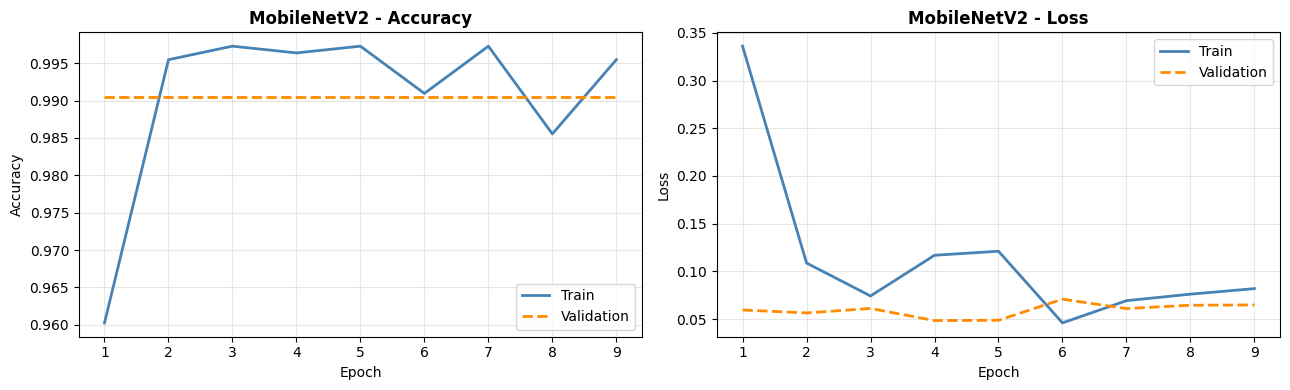

Saved -> /content/drive/MyDrive/Colab Notebooks/Osas/deep/plots/mobilenetv2_training_history.png


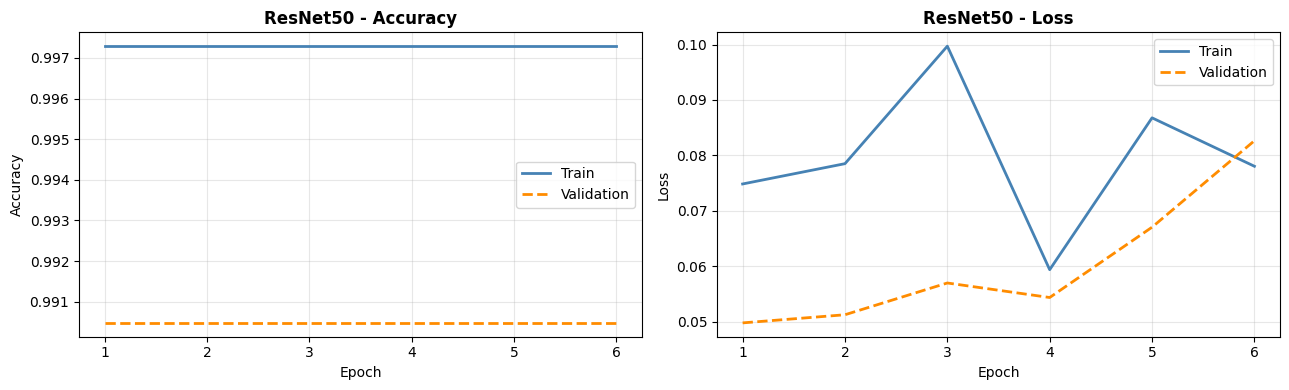

Saved -> /content/drive/MyDrive/Colab Notebooks/Osas/deep/plots/resnet50_training_history.png


In [ ]:
# -- Training History Plots ---------------------------------------------------
def plot_training_history(history, model_name):
    """
    Plots accuracy and loss curves from a single training history object.
    """
    acc      = history.history.get('accuracy', [])
    val_acc  = history.history.get('val_accuracy', [])
    loss     = history.history.get('loss', [])
    val_loss = history.history.get('val_loss', [])
    epochs_range = range(1, len(acc) + 1)

    fig, axes = plt.subplots(1, 2, figsize=(13, 4))

    axes[0].plot(epochs_range, acc,     label='Train',      color='steelblue',  lw=2)
    axes[0].plot(epochs_range, val_acc, label='Validation', color='darkorange', lw=2, linestyle='--')
    axes[0].set_title(f'{model_name} - Accuracy', fontweight='bold')
    axes[0].set_xlabel('Epoch')
    axes[0].set_ylabel('Accuracy')
    axes[0].legend()
    axes[0].grid(True, alpha=0.3)

    axes[1].plot(epochs_range, loss,     label='Train',      color='steelblue',  lw=2)
    axes[1].plot(epochs_range, val_loss, label='Validation', color='darkorange', lw=2, linestyle='--')
    axes[1].set_title(f'{model_name} - Loss', fontweight='bold')
    axes[1].set_xlabel('Epoch')
    axes[1].set_ylabel('Loss')
    axes[1].legend()
    axes[1].grid(True, alpha=0.3)

    plt.tight_layout()
    fname = f'{PLOTS_PATH}/{model_name.lower().replace(" ", "_")}_training_history.png'
    plt.savefig(fname, dpi=150)
    plt.show()
    print(f'Saved -> {fname}')


plot_training_history(history_mn, 'MobileNetV2')
plot_training_history(history_rn, 'ResNet50')


In [ ]:
#  Evaluate with Fixed 0.5 Threshold
THRESHOLD = 0.5  # fixed decision threshold

def evaluate_model(model, test_generator, model_name, threshold=THRESHOLD):
    """
    Evaluates a model on the test set using a fixed decision threshold.
    Returns y_true, y_pred, y_proba.
    """
    test_generator.reset()
    y_proba = model.predict(test_generator, verbose=1).flatten()
    y_pred  = (y_proba >= threshold).astype(int)
    y_true  = test_generator.classes

    print(f'\n{"="*55}')
    print(f'  Model     : {model_name}')
    print(f'  Threshold : {threshold}  (fixed)')
    print(f'{"="*55}')
    print(f'  Accuracy  : {accuracy_score(y_true, y_pred):.4f}')
    print(f'  Precision : {precision_score(y_true, y_pred, zero_division=0):.4f}')
    print(f'  Recall    : {recall_score(y_true, y_pred, zero_division=0):.4f}')
    print(f'  F1-Score  : {f1_score(y_true, y_pred, zero_division=0):.4f}')
    print(f'  ROC-AUC   : {roc_auc_score(y_true, y_proba):.4f}')
    print(f'\n{classification_report(y_true, y_pred, target_names=["Legitimate", "Fraudulent"], zero_division=0)}')

    return y_true, y_pred, y_proba


#  Evaluate both models on test set
test_gen = make_generator(eval_datagen, test_df, shuffle=False)
y_true_mn, y_pred_mn, y_proba_mn = evaluate_model(mobilenet_model, test_gen, 'MobileNetV2')

test_gen = make_generator(eval_datagen, test_df, shuffle=False)
y_true_rn, y_pred_rn, y_proba_rn = evaluate_model(resnet_model, test_gen, 'ResNet50')


Found 158 validated image filenames belonging to 2 classes.
5/5 ━━━━━━━━━━━━━━━━━━━━ 7s 1s/step

  Model     : MobileNetV2
  Threshold : 0.5  (fixed)
  Accuracy  : 0.9937
  Precision : 0.9937
  Recall    : 1.0000
  F1-Score  : 0.9968
  ROC-AUC   : 0.9108

              precision    recall  f1-score   support

  Legitimate       0.00      0.00      0.00         1
  Fraudulent       0.99      1.00      1.00       157

    accuracy                           0.99       158
   macro avg       0.50      0.50      0.50       158
weighted avg       0.99      0.99      0.99       158

Found 158 validated image filenames belonging to 2 classes.
5/5 ━━━━━━━━━━━━━━━━━━━━ 29s 5s/step

  Model     : ResNet50
  Threshold : 0.5  (fixed)
  Accuracy  : 0.9937
  Precision : 0.9937
  Recall    : 1.0000
  F1-Score  : 0.9968
  ROC-AUC   : 0.9809

              precision    recall  f1-score   support

  Legitimate       0.00      0.00      0.00         1
  Fraudulent       0.99      1.00      1.00       157


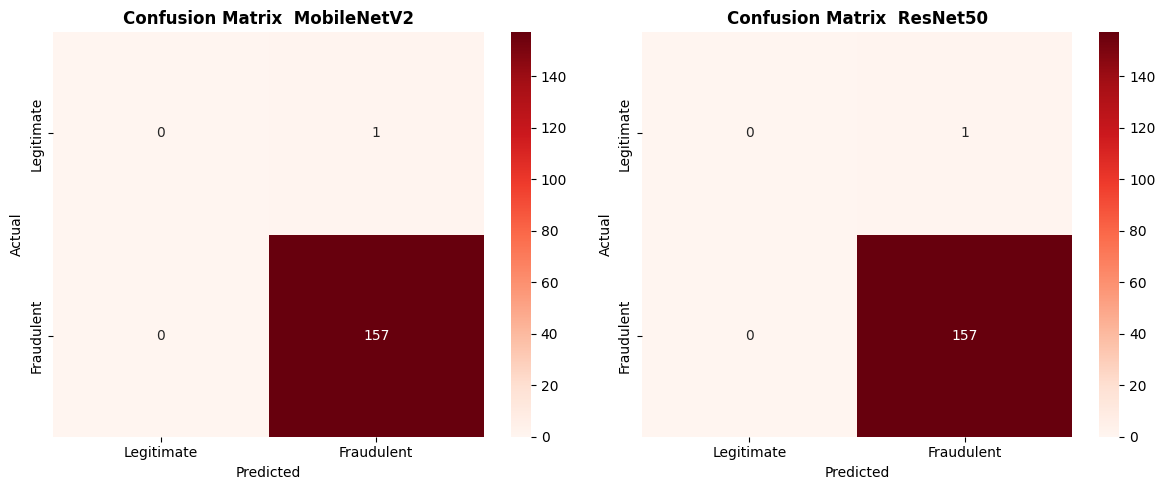

In [ ]:
#  Confusion Matrices
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

for ax, name, y_pred, y_true in [
    (axes[0], 'MobileNetV2', y_pred_mn, y_true_mn),
    (axes[1], 'ResNet50',    y_pred_rn, y_true_rn)
]:
    cm = confusion_matrix(y_true, y_pred)
    sns.heatmap(
        cm, annot=True, fmt='d', cmap='Reds',
        xticklabels=['Legitimate', 'Fraudulent'],
        yticklabels=['Legitimate', 'Fraudulent'],
        ax=ax
    )
    ax.set_title(f'Confusion Matrix  {name}', fontweight='bold')
    ax.set_ylabel('Actual')
    ax.set_xlabel('Predicted')

plt.tight_layout()
plt.savefig(f'{PLOTS_PATH}/confusion_matrices.png', dpi=150)
plt.show()

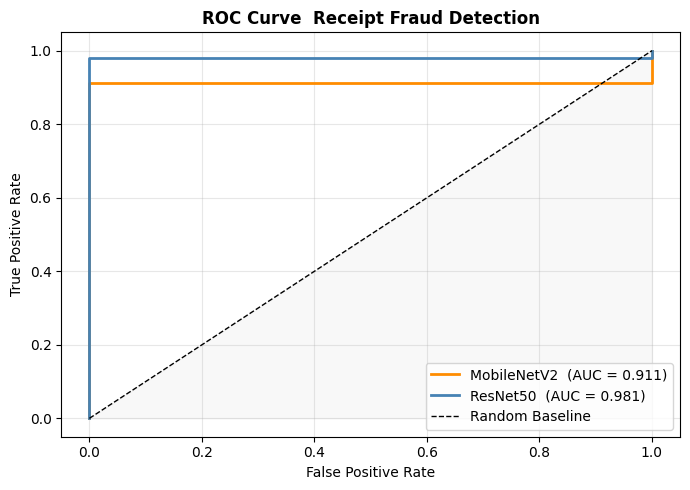

In [ ]:
#  ROC Curves
fig, ax = plt.subplots(figsize=(7, 5))

for name, y_true, y_proba, color in [
    ('MobileNetV2', y_true_mn, y_proba_mn, 'darkorange'),
    ('ResNet50',    y_true_rn, y_proba_rn, 'steelblue')
]:
    fpr, tpr, _ = roc_curve(y_true, y_proba)
    auc = roc_auc_score(y_true, y_proba)
    ax.plot(fpr, tpr, label=f'{name}  (AUC = {auc:.3f})', color=color, lw=2)

ax.plot([0,1],[0,1], 'k--', label='Random Baseline', lw=1)
ax.fill_between([0,1],[0,1], alpha=0.05, color='grey')
ax.set_xlabel('False Positive Rate')
ax.set_ylabel('True Positive Rate')
ax.set_title('ROC Curve  Receipt Fraud Detection', fontweight='bold')
ax.legend(loc='lower right')
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig(f'{PLOTS_PATH}/roc_curves.png', dpi=150)
plt.show()


  RECEIPT FRAUD DETECTION  CV MODEL COMPARISON
      Model  Accuracy  Precision  Recall  F1-Score  ROC-AUC
MobileNetV2    0.9937     0.9937     1.0    0.9968   0.9108
   ResNet50    0.9937     0.9937     1.0    0.9968   0.9809


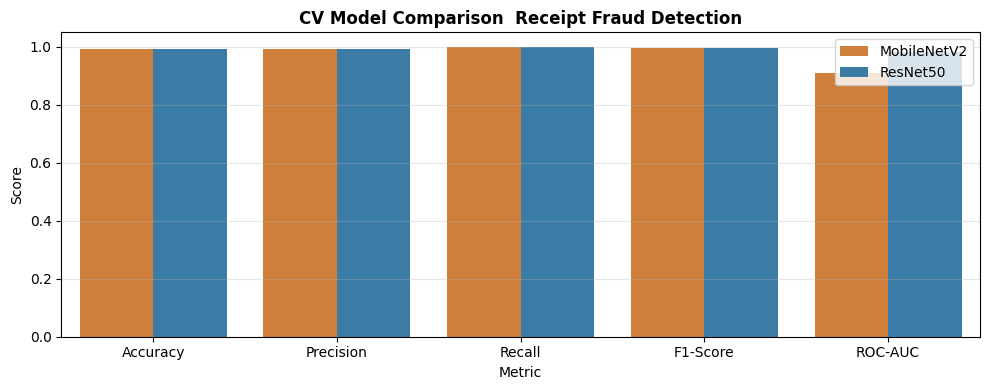

In [ ]:
#  Side-by-Side Metric Comparison
summary_df = pd.DataFrame([
    {
        'Model'    : 'MobileNetV2',
        'Accuracy' : round(accuracy_score(y_true_mn, y_pred_mn), 4),
        'Precision': round(precision_score(y_true_mn, y_pred_mn, zero_division=0), 4),
        'Recall'   : round(recall_score(y_true_mn, y_pred_mn, zero_division=0), 4),
        'F1-Score' : round(f1_score(y_true_mn, y_pred_mn, zero_division=0), 4),
        'ROC-AUC'  : round(roc_auc_score(y_true_mn, y_proba_mn), 4)
    },
    {
        'Model'    : 'ResNet50',
        'Accuracy' : round(accuracy_score(y_true_rn, y_pred_rn), 4),
        'Precision': round(precision_score(y_true_rn, y_pred_rn, zero_division=0), 4),
        'Recall'   : round(recall_score(y_true_rn, y_pred_rn, zero_division=0), 4),
        'F1-Score' : round(f1_score(y_true_rn, y_pred_rn, zero_division=0), 4),
        'ROC-AUC'  : round(roc_auc_score(y_true_rn, y_proba_rn), 4)
    }
])

print('\n' + '='*60)
print('  RECEIPT FRAUD DETECTION  CV MODEL COMPARISON')
print('='*60)
print(summary_df.to_string(index=False))
print('='*60)

# Bar chart
melt = summary_df.melt(id_vars='Model', var_name='Metric', value_name='Score')
fig, ax = plt.subplots(figsize=(10, 4))
sns.barplot(data=melt, x='Metric', y='Score', hue='Model',
            palette=['#e67e22', '#2980b9'], ax=ax)
ax.set_ylim(0, 1.05)
ax.set_title('CV Model Comparison  Receipt Fraud Detection', fontweight='bold')
ax.legend()
ax.grid(True, alpha=0.3, axis='y')
plt.tight_layout()
plt.savefig(f'{PLOTS_PATH}/model_comparison.png', dpi=150)
plt.show()

Found 158 validated image filenames belonging to 2 classes.


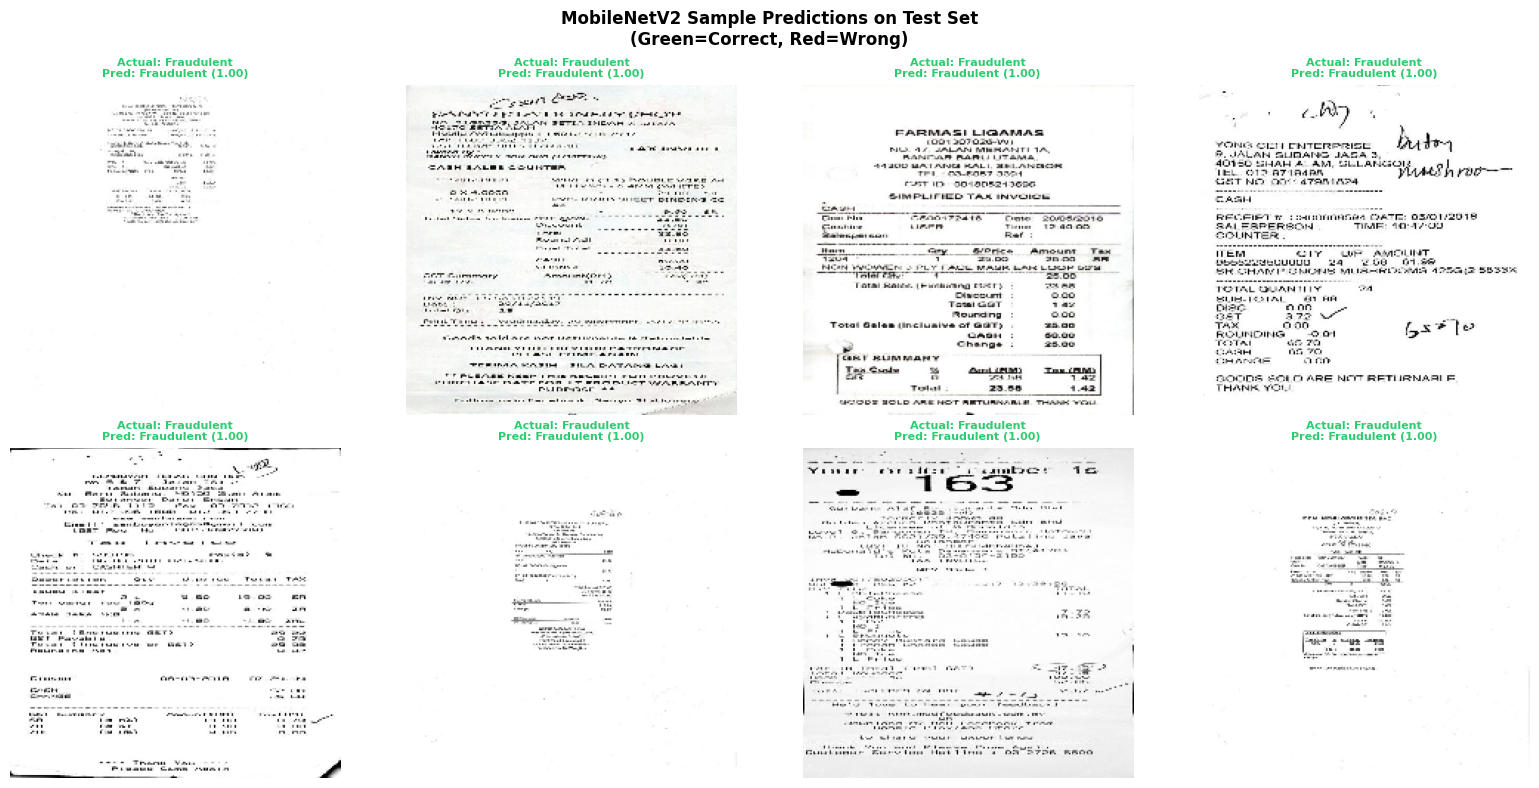

In [ ]:
#  Sample Predictions Visualisation
# Show test images with predicted vs actual labels
test_gen_viz = make_generator(eval_datagen, test_df, shuffle=False)
test_gen_viz.reset()

batch_imgs, batch_labels = next(test_gen_viz)
batch_preds = mobilenet_model.predict(batch_imgs, verbose=0).flatten()

fig, axes = plt.subplots(2, 4, figsize=(16, 8))
for i, ax in enumerate(axes.flatten()):
    if i < len(batch_imgs):
        ax.imshow(batch_imgs[i])
        actual    = 'Fraudulent' if int(batch_labels[i]) == 1 else 'Legitimate'
        predicted = 'Fraudulent' if batch_preds[i] >= THRESHOLD else 'Legitimate'
        conf      = batch_preds[i] if batch_preds[i] >= THRESHOLD else 1 - batch_preds[i]
        correct   = actual == predicted
        color     = '#2ecc71' if correct else '#e74c3c'
        ax.set_title(
            f'Actual: {actual}\nPred: {predicted} ({conf:.2f})',
            color=color, fontsize=8, fontweight='bold'
        )
    ax.axis('off')

plt.suptitle('MobileNetV2 Sample Predictions on Test Set\n(Green=Correct, Red=Wrong)',
             fontsize=12, fontweight='bold')
plt.tight_layout()
plt.savefig(f'{PLOTS_PATH}/sample_predictions.png', dpi=150)
plt.show()

## 8. Saving Models and Artefacts
<a id='8'></a>

The final section saves the trained models, configuration, and metrics. These files provide supporting evidence for the receipt-analysis work and make it possible to reuse the results without retraining from the beginning.


In [ ]:
#  Save Full Keras Models
mobilenet_model.save(f'{SAVE_PATH}/mobilenet_receipt_fraud.keras')
resnet_model.save(f'{SAVE_PATH}/resnet50_receipt_fraud.keras')

print(' Models saved:')
print(f'   {SAVE_PATH}/mobilenet_receipt_fraud.keras')
print(f'   {SAVE_PATH}/resnet50_receipt_fraud.keras')
print(f'   {SAVE_PATH}/mobilenet_best.keras  (best checkpoint)')
print(f'   {SAVE_PATH}/resnet50_best.keras   (best checkpoint)')


 Models saved:
   /content/drive/MyDrive/Colab Notebooks/Osas/deep/saved_models/mobilenet_receipt_fraud.keras
   /content/drive/MyDrive/Colab Notebooks/Osas/deep/saved_models/resnet50_receipt_fraud.keras
   /content/drive/MyDrive/Colab Notebooks/Osas/deep/saved_models/mobilenet_best.keras  (best checkpoint)
   /content/drive/MyDrive/Colab Notebooks/Osas/deep/saved_models/resnet50_best.keras   (best checkpoint)


In [ ]:
#  Save CV Config for Interface
cv_config = {
    'img_size'        : list(IMG_SIZE),
    'class_indices'   : train_gen.class_indices,
    'labels'          : ['Legitimate', 'Fraudulent'],
    'threshold'       : 0.5,
    'mobilenet_model' : 'mobilenet_receipt_fraud.keras',
    'resnet_model'    : 'resnet50_receipt_fraud.keras',
    'description'     : 'Binary classifier: 0=Legitimate receipt, 1=Fraudulent receipt'
}

config_path = f'{SAVE_PATH}/cv_config.json'
with open(config_path, 'w') as f:
    json.dump(cv_config, f, indent=2)

print(f' Config saved: {config_path}')
print(json.dumps(cv_config, indent=2))


 Config saved: /content/drive/MyDrive/Colab Notebooks/Osas/deep/saved_models/cv_config.json
{
  "img_size": [
    224,
    224
  ],
  "class_indices": {
    "0": 0,
    "1": 1
  },
  "labels": [
    "Legitimate",
    "Fraudulent"
  ],
  "threshold": 0.5,
  "mobilenet_model": "mobilenet_receipt_fraud.keras",
  "resnet_model": "resnet50_receipt_fraud.keras",
  "description": "Binary classifier: 0=Legitimate receipt, 1=Fraudulent receipt"
}


In [ ]:
#  Save Model Metrics for Interface Dashboard
metrics_to_save = {
    'MobileNetV2': {
        'accuracy'  : round(accuracy_score(y_true_mn, y_pred_mn), 4),
        'precision' : round(precision_score(y_true_mn, y_pred_mn, zero_division=0), 4),
        'recall'    : round(recall_score(y_true_mn, y_pred_mn, zero_division=0), 4),
        'f1_score'  : round(f1_score(y_true_mn, y_pred_mn, zero_division=0), 4),
        'roc_auc'   : round(roc_auc_score(y_true_mn, y_proba_mn), 4),
        'threshold' : 0.5
    },
    'ResNet50': {
        'accuracy'  : round(accuracy_score(y_true_rn, y_pred_rn), 4),
        'precision' : round(precision_score(y_true_rn, y_pred_rn, zero_division=0), 4),
        'recall'    : round(recall_score(y_true_rn, y_pred_rn, zero_division=0), 4),
        'f1_score'  : round(f1_score(y_true_rn, y_pred_rn, zero_division=0), 4),
        'roc_auc'   : round(roc_auc_score(y_true_rn, y_proba_rn), 4),
        'threshold' : 0.5
    }
}

metrics_path = f'{SAVE_PATH}/cv_metrics.json'
with open(metrics_path, 'w') as f:
    json.dump(metrics_to_save, f, indent=2)

print(f' Metrics saved: {metrics_path}')

#  Final File Listing
print('\n All saved artefacts:')
for fname in sorted(os.listdir(SAVE_PATH)):
    size = os.path.getsize(os.path.join(SAVE_PATH, fname))
    print(f'   {fname:50s}  ({size/1024:.1f} KB)')

print('\n All saved plots:')
for fname in sorted(os.listdir(PLOTS_PATH)):
    print(f'   {fname}')


 Metrics saved: /content/drive/MyDrive/Colab Notebooks/Osas/deep/saved_models/cv_metrics.json

 All saved artefacts:
   cv_config.json                                      (0.3 KB)
   cv_metrics.json                                     (0.3 KB)
   mobilenet_best.keras                                (13485.4 KB)
   mobilenet_receipt_fraud.keras                       (13485.4 KB)
   resnet50_best.keras                                 (99201.4 KB)
   resnet50_receipt_fraud.keras                        (99201.4 KB)

 All saved plots:
   annotation_count_distribution.png
   annotation_distribution.png
   augmented_samples.png
   class_balance.png
   confusion_matrices.png
   mobilenetv2_training_history.png
   model_comparison.png
   resnet50_training_history.png
   roc_curves.png
   sample_images.png
   sample_predictions.png
